In [2]:
import pandas as pd
RAW_DATA_PATH = '../experiments/output.csv'  # Path to raw data
df_raw = pd.read_csv(RAW_DATA_PATH)


In [3]:
df_raw.isnull().values.any()

np.False_

In [3]:
### --- Calculate the range (0-1kWh) ---
RAW_DATA_PATH = '../experiments/output.csv'  # Path to raw data
df_raw = pd.read_csv(RAW_DATA_PATH)

# for global values
min_val = df_raw['KWH/hh (per half hour) '].min()
max_val = df_raw['KWH/hh (per half hour) '].max()

# for effective 95% range
median_val = df_raw['KWH/hh (per half hour) '].median() # compute the median
distances = (df_raw['KWH/hh (per half hour) '] - median_val).abs() # create a serie where each row contains a distance to the median
cutoff = distances.quantile(0.965) # find the cuttof for the top 5% most extreme distances
df_trimmed = df_raw[distances <= cutoff] # keep only the 95% of the closest values
trimmed_min_value = df_trimmed['KWH/hh (per half hour) '].min()
trimmed_max_value = df_trimmed['KWH/hh (per half hour) '].max()

print(f"Global Range: {max_val - min_val:.2f}")
print(f"Effective 96.5% Range: {trimmed_max_value - trimmed_min_value:.2f}")

Global Range: 9.26
Effective 96.5% Range: 1.00


In [20]:
import pandas as pd
import time
from collections import Counter
import matplotlib.pyplot as plt

df = pd.read_csv(RAW_DATA_PATH, index_col=False)
df.drop(columns=["stdorToU"], axis=1, inplace=True) # drop the stdortou column -> 3 columns

lclids = sorted(df['LCLid'].unique())
groups = [lclids[i:i+100] for i in range(0, len(lclids), 100)]

total_publication_ratio = 0

for n in range(len(groups)):
    # select rows for macs that in groups[n]
    mask = df['LCLid'].isin(groups[n]) # keep only rows that are in group [n]
    df_temporary = df[mask]

    
    all_frequencies = {}
    for timestamp, group in df_temporary.groupby('DateTime'):
        all_frequencies[timestamp] = Counter(group['KWH/hh (per half hour) '])
    
    build_time = time.time() - start_time    
    
    results = [] # keep the results in the form of a list with tuples containing the z for which it was tested, number of tuples published for this z 
    # and publication ratio
    max_z_to_test = 500
    z_values = range(1, max_z_to_test + 1)
    
    start_eval_time = time.time()
    total_tuples = len(df_temporary)
    for z in z_values:
        total_published_for_this_z = 0
        for timestamp in all_frequencies:
            for count in all_frequencies[timestamp].values():
                if count >= z:
                    total_published_for_this_z += (count - (z-1))
        
        if total_published_for_this_z == 0:
            break
    
        publication_ratio = (total_published_for_this_z / total_tuples) * 100
            
            
        results.append({'z': z, 'published_tuples': total_published_for_this_z, 'publication_ratio': publication_ratio})

        if z == 2:
            total_publication_ratio += publication_ratio

avg_pub_ratio = total_publication_ratio / 56

eval_time = time.time() - start_eval_time
# print(f"Evaluated {len(results)} z-values in {eval_time:.4f} seconds.")
avg_pub_ratio # Only 12.8% of the tuples are forwarded to the global entity for local_z=2.

12.759363560574505

In [16]:
for n in range(len(groups)):
    # select rows for macs that in groups[n]
    mask = df['LCLid'].isin(groups[n]) # keep only rows that are in group [n]
    df_temporary = df[mask]
    if n > 0:
        break
df_temporary


,LCLid,DateTime,KWH/hh (per half hour)
410446,MAC000106,2012-11-05 00:00:00,0.236
410447,MAC000106,2012-11-05 00:30:00,0.092
410448,MAC000106,2012-11-05 01:00:00,0.121
410449,MAC000106,2012-11-05 01:30:00,0.124
410450,MAC000106,2012-11-05 02:00:00,0.130
...,...,...,...
1327998,MAC000201,2012-11-11 21:30:00,0.202
1327999,MAC000201,2012-11-11 22:00:00,1.578
1328000,MAC000201,2012-11-11 22:30:00,0.125
1328001,MAC000201,2012-11-11 23:00:00,0.099



Sample of results:
   z  published_tuples  publication_ratio
0  1             33409         100.000000
1  2              4112          12.308061
2  3               544           1.628304
3  4                65           0.194558
4  5                 5           0.014966

Result for z=50:
Empty DataFrame
Columns: [z, published_tuples, publication_ratio]
Index: []


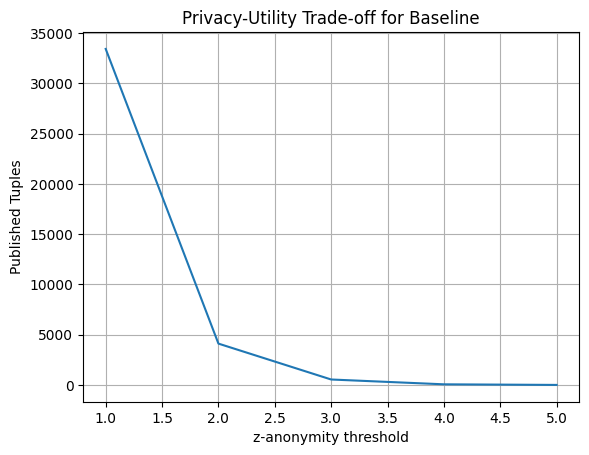

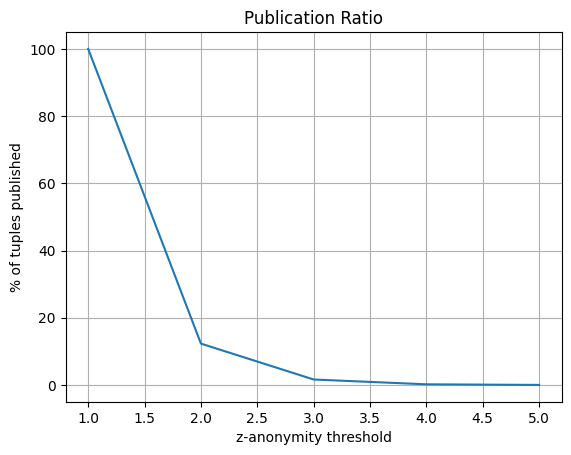

In [18]:
results_df = pd.DataFrame(results)
print("\nSample of results:")
print(results_df.head())
print("\nResult for z=50:")
print(results_df[results_df['z'] == 50])

# You can now easily plot this to see the privacy-utility trade-off
# import matplotlib.pyplot as plt
plt.plot(results_df['z'], results_df['published_tuples'])
plt.xlabel("z-anonymity threshold")
plt.ylabel("Published Tuples")
plt.title("Privacy-Utility Trade-off for Baseline")
plt.grid(True)
plt.show()

plt.plot(results_df['z'], results_df['publication_ratio'])
plt.xlabel("z-anonymity threshold")
plt.ylabel("% of tuples published")
plt.title("Publication Ratio")
plt.grid(True)
plt.show()